Bike Rental Prediction in a given hour from weather , season and time of day

Dataset: hour.ipynb


Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load the dataset

In [3]:
df=pd.read_csv("hour.csv")

Check total rows and columns

In [4]:
df.shape

(17379, 17)

Check first few rows

In [5]:
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Check the data and its types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


The above dataset has numerical data type such as temp, atemp, hum,winspeed, casual, registered , cnt as they represent counts only no particular pattern. Categorical data are season, yr, mnth, hr, holiday, weekday, workingday, weathersit among which season and weathersit are ordinal data while others categorical data like yr, mnth, hr, holiday, weekday, workingday represents labels are nominal

In [7]:

cat_cols = ["season","yr","mnth","hr","holiday","weekday", "workingday","weathersit"]

num_cols = ["temp","atemp","hum","windspeed","casual", "registered","cnt"]

Check for missing values

In [8]:
print("Missing values", df.isnull().sum())

Missing values instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Overall data summary

In [9]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Convert dteday to datetime because dteday is read as text by default and by converting it to datetime makes it a real date column previously in df.info we say it as object data type

In [5]:
df["dteday"] = pd.to_datetime(df["dteday"])


In [12]:
df.info()

df.duplicated().sum()

df.isnull().sum()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Univariate analysis for categorical variables

Univariate Analysis: Categorical Variables

Column: season


,Count,Percentage
season,,
1,4242,24.41
2,4409,25.37
3,4496,25.87
4,4232,24.35


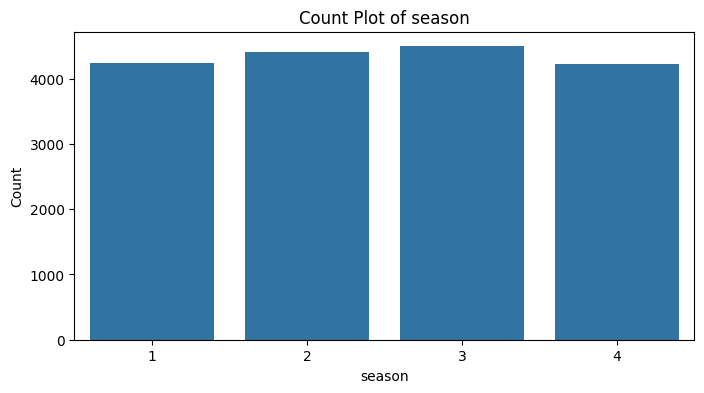


Column: hr


,Count,Percentage
hr,,
0,726,4.18
1,724,4.17
2,715,4.11
3,697,4.01
4,697,4.01
5,717,4.13
6,725,4.17
7,727,4.18
8,727,4.18


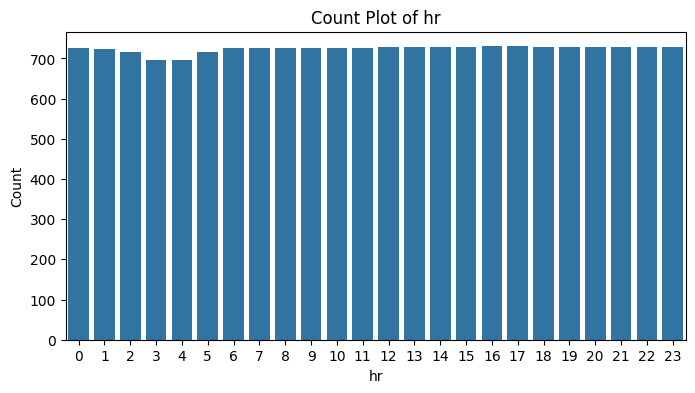


Column: weathersit


,Count,Percentage
weathersit,,
1,11413,65.67
2,4544,26.15
3,1419,8.17
4,3,0.02


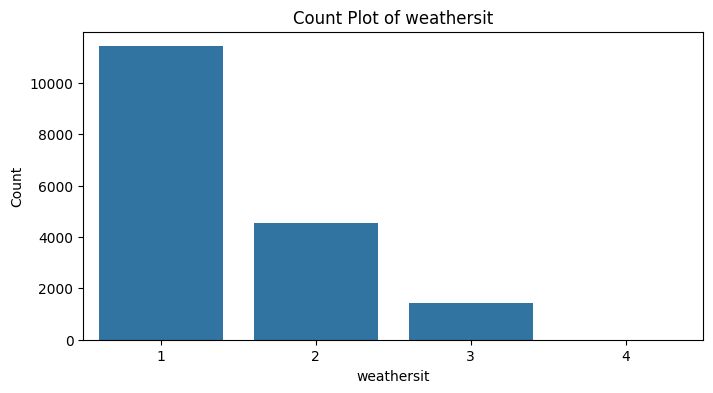

,total_rentals,avg_rentals,observations
season_name,,,
fall,1061129,236.016237,4496
spring,471348,111.114569,4242
summer,918589,208.344069,4409
winter,841613,198.868856,4232


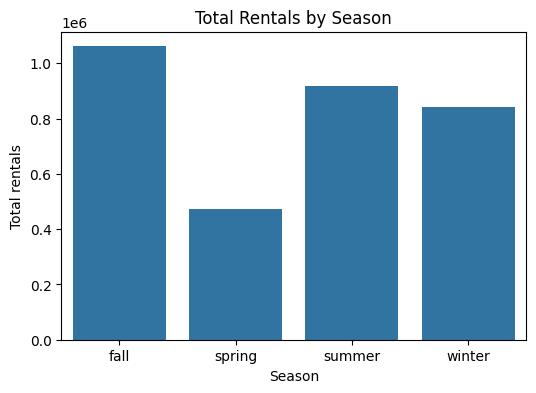

In [21]:
cat_cols = ["season", "hr", "weathersit"]

print("Univariate Analysis: Categorical Variables")

for col in cat_cols:
    print(f"\nColumn: {col}")
    
    count = df[col].value_counts().sort_index()
    percent = round(df[col].value_counts(normalize=True).sort_index()*100, 2)
    
    summary_table = pd.DataFrame({"Count": count,"Percentage": percent})
    display(summary_table)
    
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()


    season_map = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
df["season_name"] = df["season"].map(season_map)

rentals_by_season = df.groupby("season_name")["cnt"].agg(total_rentals="sum", avg_rentals="mean", observations="count")
display(rentals_by_season)

# quick plot of total rentals
plt.figure(figsize=(6,4))
sns.barplot(x=rentals_by_season.index, y=rentals_by_season["total_rentals"].values)
plt.title("Total Rentals by Season")
plt.ylabel("Total rentals")
plt.xlabel("Season")
plt.show()

More people rent bikes in warmer seasons, especially summer and fall, than in winter. The table shows both the raw number of rentals and the average rentals, so the pattern is not just from the number of rows but from higher demand.

Bike rentals are highest around the morning and evening hours, which suggests commuting behavior. The count plot helps show which hours appear most often, and the rental summary by hour should be used to prove the peak demand hours.

Clear and pleasant weather has the highest rentals, while bad weather has the lowest. The numbers and the bar chart together show that weather strongly affects demand.

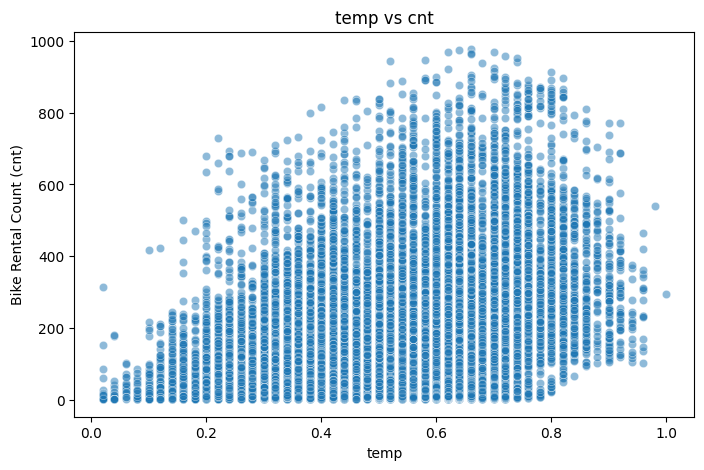

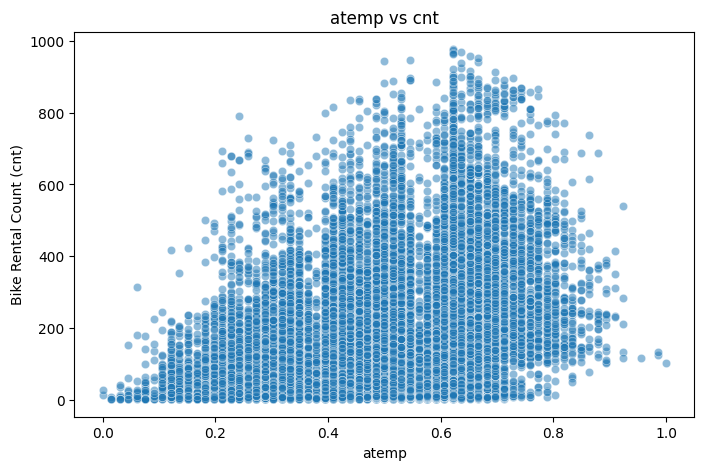

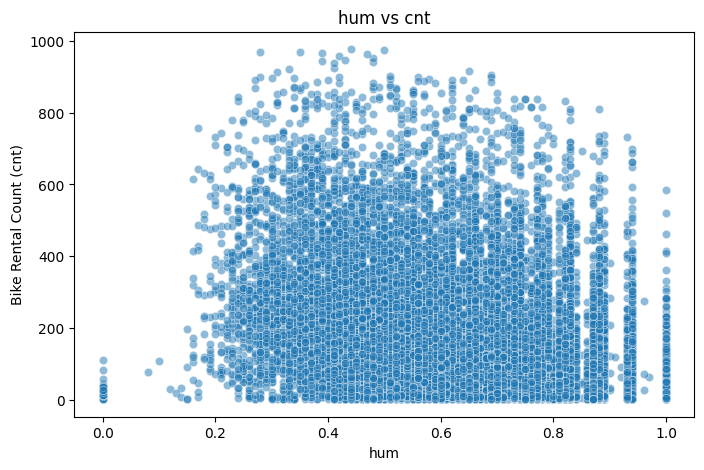

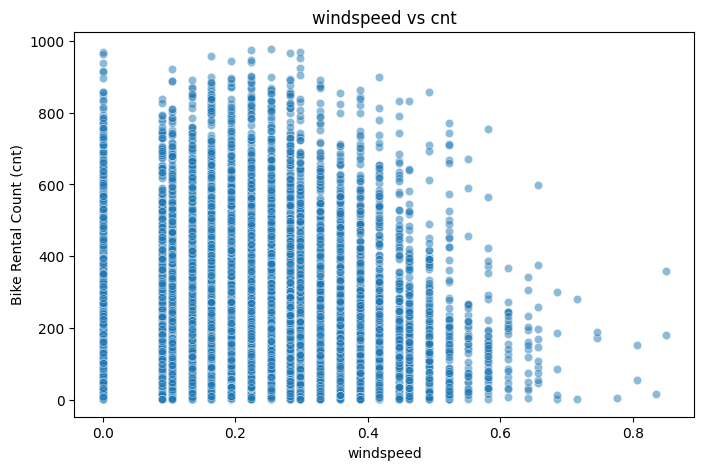

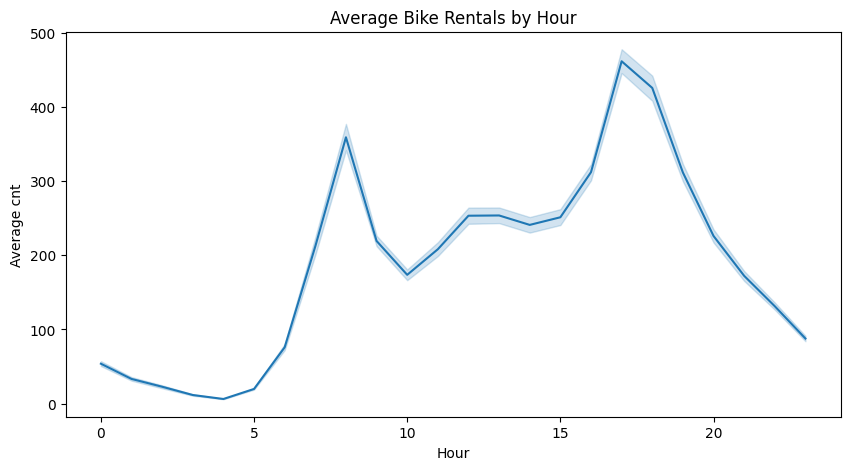

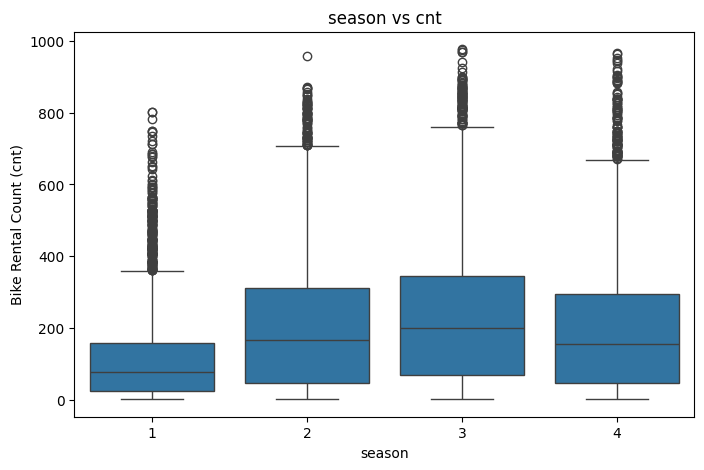

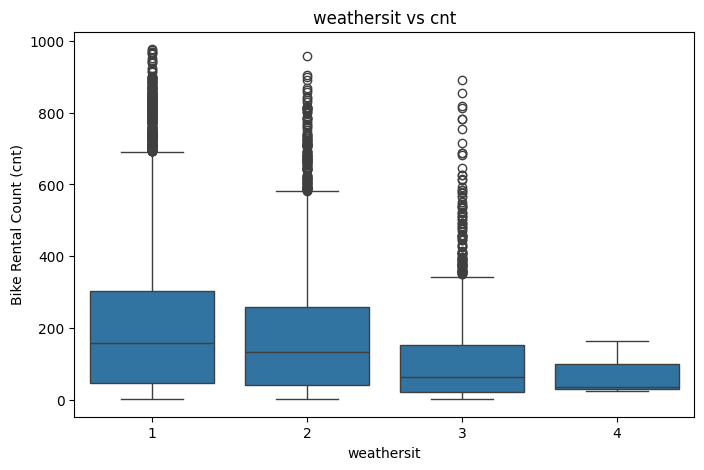


 season vs weathersit


weathersit,1,2,3,4
season,,,,
1,2665,1205,369,3
2,2859,1144,406,0
3,3280,947,269,0
4,2609,1248,375,0


In [23]:
numeric_features_vs_target = ["temp", "atemp", "hum", "windspeed"]

for feature in numeric_features_vs_target:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df["cnt"], alpha=0.5)
    plt.title(f"{feature} vs cnt")
    plt.xlabel(feature)
    plt.ylabel("Bike Rental Count (cnt)")
    plt.show()

# Time trend: hour vs cnt
plt.figure(figsize=(10, 5))
sns.lineplot(x="hr", y="cnt", data=df, estimator="mean")
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average cnt")
plt.show()

categorical_features_vs_target = ["season", "weathersit"]

for feature in categorical_features_vs_target:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=feature, y="cnt", data=df)
    plt.title(f"{feature} vs cnt")
    plt.xlabel(feature)
    plt.ylabel("Bike Rental Count (cnt)")
    plt.show()

season_weather_crosstab = pd.crosstab(df["season"], df["weathersit"])
print("\n season vs weathersit")
display(season_weather_crosstab)

The scatter plots and box plots show that bike rentals change with weather, season, and temperature. Rentals are higher in good weather and warmer conditions, while poor weather and extreme conditions reduce demand. The hour plot also shows clear peaks during commute times, which means time of day strongly affects rental count.

Multivariate analysis

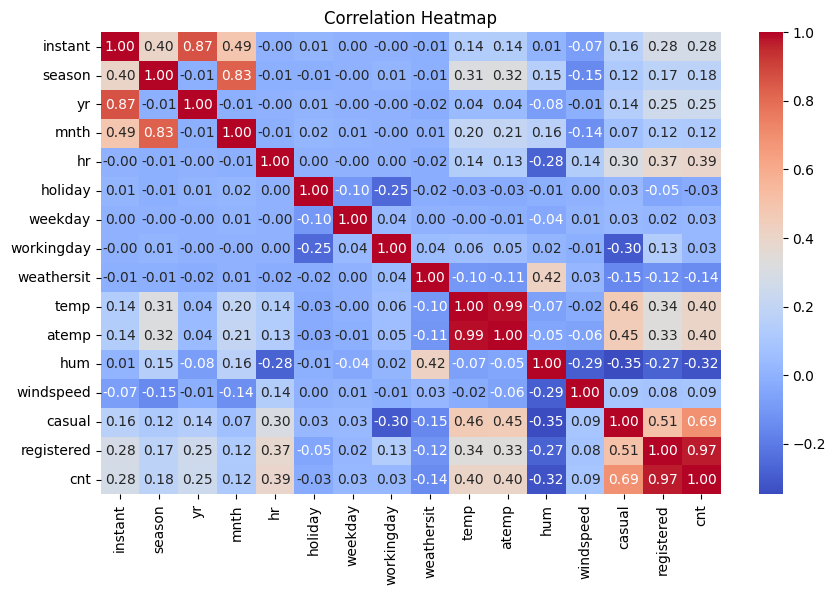

In [24]:
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Select features and target

In [25]:
features = ['season', 'hr', 'temp', 'hum', 'windspeed', 'weathersit', 'workingday']
X = df[features]
y = df['cnt']

Train test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


Training data shape: (13903, 7)
Testing data shape: (3476, 7)


Error calculation

In [ ]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

MSE:  20807.24
RMSE: 144.25
MAE:  106.96
R²:   0.3429


Plot

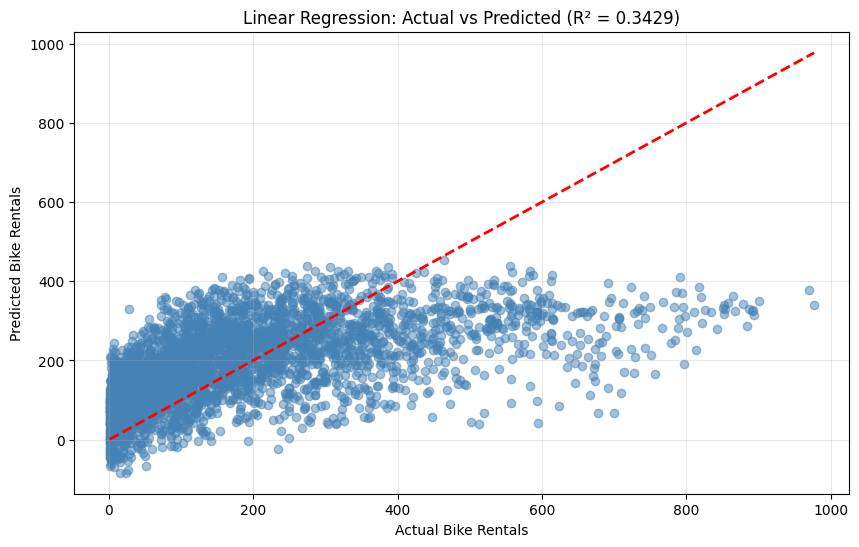

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title(f'Linear Regression: Actual vs Predicted (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)
plt.savefig('linear_regression.png', dpi=150)
plt.show()


Sample Predictions


,Actual,Predicted
0,425,420.250594
1,88,193.443077
2,4,95.688641
3,526,345.635898
4,13,24.558493
5,32,39.526241
6,706,304.676538
7,26,59.465547
8,2,79.556426
9,21,135.008090


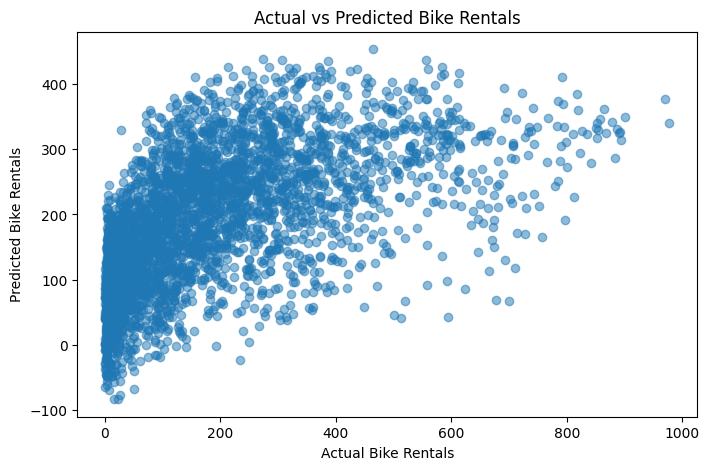

In [33]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions")
display(results.head(10))

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")
plt.show()

Conclusion
The hour.csv dataset is clean and contains no missing values. The main preprocessing step was converting the dteday column into a datetime format so that date and time information could be analyzed properly.

The analysis showed that bike rental demand is affected by the season, weather, and time of day. More bikes are rented during warm seasons and good weather, while rentals decrease during cold seasons and poor weather conditions.

Rental demand is highest during the morning and evening hours. This suggests that many people use rental bikes for commuting and other daily travel needs.

The model was built using 7 features: season, hr, temp, hum, windspeed, weathersit, and workingday.

The data was split into 13,903 rows for training and 3,476 rows for testing to evaluate the model's performance.

The Linear Regression model achieved an MSE of 20807.24, RMSE of 144.25, MAE of 106.96, and an R² score of 0.3429. This means the model can identify some of the demand patterns, but it is not able to explain all of the changes in bike rentals.

Overall, bike rental demand follows clear patterns and is not random. 